# LABORATORIO 3 — Exploración de Datos en Big Data

**Curso:** Analítica de Datos (202W1001 — Plan 2023)

**Escuela:** E.P. Ingeniería de Software — Facultad de Ingeniería de Sistemas e Informática — UNMSM

**Estudiante:** Luis Calle Huamantinco

**Código:** 22200255

**Semestre académico:** 2026-2 | Ciclo X | Unidad I

**Fecha:** 08/09/2026

**Docente:** Mg. Juan Gamarra Moreno

## PASO 0 — Preparación

In [1]:
import duckdb, polars as pl, pandas as pd, numpy as np
import matplotlib.pyplot as plt
import os, time
CSV = "ventas_2022_2026.csv.gz"
assert os.path.exists(CSV), "No se encuentra el archivo de datos en esta carpeta"
con = duckdb.connect()          # base en memoria
os.makedirs("lago", exist_ok=True)
print("duckdb", duckdb.__version__, "| polars", pl.__version__)
print("tamaño del archivo: %.1f MB" % (os.path.getsize(CSV)/ 1e6))

duckdb 1.5.5 | polars 1.44.1
tamaño del archivo: 13.2 MB


## PASO 1 — Primera inspección sin cargar el archivo completo

In [2]:
# 1.a  Primeras filas: DuckDB lee solo lo necesario
con.sql(f"SELECT * FROM read_csv_auto('{CSV}') LIMIT 5").show()

┌──────────────┬─────────────────────┬───────────┬──────────┬─────────────┬──────────────────┬──────────┬─────────────────┬─────────┬────────────┬────────────────┐
│  id_ticket   │     fecha_hora      │ id_tienda │  region  │ id_producto │    categoria     │ cantidad │ precio_unitario │ importe │ id_cliente │   medio_pago   │
│   varchar    │      timestamp      │  varchar  │ varchar  │   varchar   │     varchar      │  int64   │     double      │ double  │  varchar   │    varchar     │
├──────────────┼─────────────────────┼───────────┼──────────┼─────────────┼──────────────────┼──────────┼─────────────────┼─────────┼────────────┼────────────────┤
│ TK0000022379 │ 2022-01-01 00:04:02 │ T081      │ LIMA     │ P07501      │ CARNES           │        8 │            28.2 │   225.6 │ C0256881   │ TARJETA_DEBITO │
│ TK0000271995 │ 2022-01-01 00:07:42 │ T011      │ LIMA     │ P02566      │ PANADERIA        │        6 │            5.96 │   35.76 │ C0305584   │ EFECTIVO       │
│ TK0000498525 │

In [3]:
# 1.b  Esquema inferido y tipos de dato
con.sql(f"DESCRIBE SELECT * FROM read_csv_auto('{CSV}')").show()

┌─────────────────┬─────────────┬─────────┬─────────┬─────────┬─────────┐
│   column_name   │ column_type │  null   │   key   │ default │  extra  │
│     varchar     │   varchar   │ varchar │ varchar │ varchar │ varchar │
├─────────────────┼─────────────┼─────────┼─────────┼─────────┼─────────┤
│ id_ticket       │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ fecha_hora      │ TIMESTAMP   │ YES     │ NULL    │ NULL    │ NULL    │
│ id_tienda       │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ region          │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ id_producto     │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ categoria       │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ cantidad        │ BIGINT      │ YES     │ NULL    │ NULL    │ NULL    │
│ precio_unitario │ DOUBLE      │ YES     │ NULL    │ NULL    │ NULL    │
│ importe         │ DOUBLE      │ YES     │ NULL    │ NULL    │ NULL    │
│ id_cliente      │ VARCHAR     │ YES 

In [4]:
# 1.c  Volumen total
n = con.sql(f"SELECT count(*) FROM read_csv_auto('{CSV}')").fetchone()[0]
print(f"{n:,} filas")

492,830 filas


**P1.** Para inferir el tipo de cada columna, DuckDB no leyó el archivo completo: solo tomó una muestra inicial de filas (por defecto lee un bloque de filas al comienzo del archivo) y de ahí dedujo si era VARCHAR, BIGINT, DOUBLE o TIMESTAMP. Esa inferencia podría fallar en un archivo mucho más grande porque una columna puede empezar pareciendo un tipo (por ejemplo, todo enteros en las primeras filas) y más adelante en el archivo aparecer un valor que no calza con ese tipo (texto, un decimal, un nulo con otra forma), y como la muestra ya pasó, DuckDB se equivocaría o lanzaría un error al llegar a esa fila.

In [5]:
# P2: rango real de fecha_hora
con.sql(f"SELECT min(fecha_hora) AS minimo, max(fecha_hora) AS maximo FROM read_csv_auto('{CSV}')").show()

┌─────────────────────┬─────────────────────┐
│       minimo        │       maximo        │
│      timestamp      │      timestamp      │
├─────────────────────┼─────────────────────┤
│ 2022-01-01 00:04:02 │ 2027-03-15 10:30:00 │
└─────────────────────┴─────────────────────┘



**P2.** El mínimo de fecha_hora es 2022-01-01 00:04:02, que sí coincide con lo declarado (enero de 2022). Pero el máximo es 2027-03-15 10:30:00, y el conjunto decía que llegaba hasta julio de 2026. O sea que no coincide: hay registros con fecha posterior al periodo que el conjunto dice cubrir.

## PASO 2 — Construir el lago de datos particionado en Parquet

In [6]:
t0 = time.time()
con.sql(f"""
COPY (
  SELECT *, year(fecha_hora) AS anio, month(fecha_hora) AS mes
  FROM read_csv_auto('{CSV}')
) TO 'lago/ventas'
(FORMAT PARQUET, PARTITION_BY (anio, mes),
 OVERWRITE_OR_IGNORE, COMPRESSION zstd)
""")
print(f"conversión completada en {time.time() - t0:.1f} s")
PQ = "lago/ventas/**/*.parquet"          # patrón que usaremos en adelante
tam_csv = os.path.getsize(CSV) / 1e6
tam_pq  = sum(os.path.getsize(os.path.join(r, f))
              for r, _, fs in os.walk("lago/ventas") for f in fs) / 1e6
n_arch  = sum(len(fs) for _, _, fs in os.walk("lago/ventas"))
print(f"CSV.gz  : {tam_csv:6.1f} MB")
print(f"Parquet : {tam_pq:6.1f} MB en {n_arch} archivos")

conversión completada en 0.6 s
CSV.gz  :   13.2 MB
Parquet :   11.4 MB en 56 archivos


In [7]:
# Exploración del árbol de directorios generado
for anio_dir in sorted(os.listdir("lago/ventas")):
    print(anio_dir, sorted(os.listdir(f"lago/ventas/{anio_dir}")))

anio=2022 ['mes=1', 'mes=10', 'mes=11', 'mes=12', 'mes=2', 'mes=3', 'mes=4', 'mes=5', 'mes=6', 'mes=7', 'mes=8', 'mes=9']
anio=2023 ['mes=1', 'mes=10', 'mes=11', 'mes=12', 'mes=2', 'mes=3', 'mes=4', 'mes=5', 'mes=6', 'mes=7', 'mes=8', 'mes=9']
anio=2024 ['mes=1', 'mes=10', 'mes=11', 'mes=12', 'mes=2', 'mes=3', 'mes=4', 'mes=5', 'mes=6', 'mes=7', 'mes=8', 'mes=9']
anio=2025 ['mes=1', 'mes=10', 'mes=11', 'mes=12', 'mes=2', 'mes=3', 'mes=4', 'mes=5', 'mes=6', 'mes=7', 'mes=8', 'mes=9']
anio=2026 ['mes=1', 'mes=2', 'mes=3', 'mes=4', 'mes=5', 'mes=6', 'mes=7']
anio=2027 ['mes=3']


**P3.** El periodo declarado es de enero de 2022 a julio de 2026 (55 meses), pero en el árbol aparece una carpeta extra: `anio=2027/mes=3`, con un solo mes. Esa es la partición sobrante. Esto confirma lo que ya se había visto en P2: hay ventas registradas con fecha 2027-03-15, fuera del periodo que el conjunto dice cubrir. Probablemente sea un error de carga o de reloj en el sistema origen, no un dato real del periodo.

**P4.** El Parquet pesa menos (11.4 MB) que el CSV.gz (13.2 MB) a pesar de tener dos columnas más, porque Parquet es un formato columnar: guarda cada columna por separado y aplica compresión específica según el tipo y la repetición de valores de esa columna (por ejemplo id_tienda o categoria tienen pocos valores distintos y comprimen muy bien). Además usa zstd, que en este caso comprime mejor que gzip sobre el CSV. Las columnas anio y mes casi no pesan porque además de ser enteros pequeños y repetitivos, se usan como partición (van en el nombre de la carpeta, no se repiten dentro de cada archivo).

## PASO 3 — Perfilado automático con SUMMARIZE

In [8]:
perfil = con.sql(f"SUMMARIZE SELECT * FROM '{PQ}'").df()
perfil[["column_name", "column_type", "min", "max",
        "approx_unique", "null_percentage"]]

,column_name,column_type,min,max,approx_unique,null_percentage
0,id_ticket,VARCHAR,TK0000000001,TK0000500000,733793,0.00
1,fecha_hora,TIMESTAMP,2022-01-01 00:04:02,2027-03-15 10:30:00,469561,0.00
2,id_tienda,VARCHAR,T001,T120,165,0.00
3,region,VARCHAR,LIMA,lima,18,0.00
4,id_producto,VARCHAR,P00001,P08500,9042,0.00
5,categoria,VARCHAR,ABARROTES,PANADERIA,10,0.00
6,cantidad,BIGINT,1,4990,225,0.00
7,precio_unitario,DOUBLE,0.97,999999.0,7389,0.00
8,importe,DOUBLE,-6999993.0,11342496.39,22785,0.00
9,id_cliente,VARCHAR,C0000001,C0480000,245050,8.26


**P5.** Con una sola instrucción (SUMMARIZE) salieron a la vista al menos seis anomalías: fecha_hora con máximo en 2027, region con min="LIMA" y max="lima" (18 valores distintos cuando deberían ser 6), precio_unitario con máximo 999999, importe con mínimo negativo y máximo de más de 11 millones, cantidad con máximo de casi 5000 unidades, e id_cliente con 8.26% de nulos. Revisar esto columna por columna a mano, para once columnas, habría tomado mucho más tiempo y seguramente se me habría pasado alguna (sobre todo el detalle de las mayúsculas/minúsculas en region, que a simple vista con `.head()` no se nota). El perfilado automatizado vale la pena porque en segundos da un mapa de por dónde hay que empezar a desconfiar de los datos.

In [9]:
# P6: nulos reales de medio_pago
con.sql(f"""SELECT count(*) FILTER (WHERE medio_pago IS NULL) AS nulos_reales,
                   count(*) FILTER (WHERE medio_pago = '') AS vacios_string
            FROM '{PQ}'""").show()

┌──────────────┬───────────────┐
│ nulos_reales │ vacios_string │
│    int64     │     int64     │
├──────────────┼───────────────┤
│         5938 │             0 │
└──────────────┴───────────────┘



**P6.** La consulta muestra 5 938 filas con medio_pago realmente NULL (y 0 con string vacío), lo que en porcentaje sí es un valor distinto de 0. La discrepancia con lo que a veces reporta SUMMARIZE se debe a que un campo vacío en el CSV original no siempre se convierte automáticamente en NULL: depende de cómo el motor de lectura interprete la celda vacía al inferir tipos. Si en algún momento esa columna se leyó como si el vacío fuera un string "" en lugar de un NULL real, el conteo de null_percentage no lo captura, porque para SQL una cadena vacía no es lo mismo que un valor nulo.

## PASO 4 — Comprobar la poda de particiones

In [10]:
# 4.a  Misma agregación, con y sin filtro de partición
t0 = time.time()
r1 = con.sql(f"SELECT count(*), round(sum(importe)) FROM '{PQ}'").fetchone()
t_todo = time.time() - t0
t0 = time.time()
r2 = con.sql(f"""SELECT count(*), round(sum(importe)) FROM '{PQ}'
                 WHERE anio = 2026 AND mes = 7""").fetchone()
t_poda = time.time() - t0
print(f"sin filtro : {r1}  ->  {t_todo*1000:6.0f} ms")
print(f"con poda   : {r2}  ->  {t_poda*1000:6.0f} ms")
print(f"aceleración: {t_todo/t_poda:.1f}x")

sin filtro : (492830, 1286852581.0)  ->       9 ms
con poda   : (9117, 14389449.0)  ->       7 ms
aceleración: 1.4x


In [11]:
# 4.b  El plan de ejecución: la evidencia de la poda
plan = con.sql(f"""EXPLAIN SELECT count(*) FROM '{PQ}'
                   WHERE anio = 2026 AND mes = 7""").fetchone()[1]
print(plan)

┌───────────────────────────┐
│    UNGROUPED_AGGREGATE    │
│    ────────────────────   │
│        Aggregates:        │
│        count_star()       │
└─────────────┬─────────────┘
┌─────────────┴─────────────┐
│        PARQUET_SCAN       │
│    ────────────────────   │
│         Function:         │
│        PARQUET_SCAN       │
│                           │
│       File Filters:       │
│   (anio = 2026)(mes = 7)  │
│                           │
│    Scanning Files: 1/56   │
│                           │
│        ~9,285 rows        │
└───────────────────────────┘



**P7.** La línea del plan dice `Scanning Files: 1/56`. Eso significa que de los 56 archivos Parquet que tiene el lago, el motor solo abrió 1. En proporción, evitó leer 55/56 de los archivos, es decir, cerca del 98% de los datos ni siquiera se tocó.

In [12]:
# Mismo resultado, dos formulaciones del filtro
for etiqueta, condicion in [("columna de partición", "anio = 2026"),
                           ("expresión derivada",  "year(fecha_hora) = 2026")]:
    sql = f"SELECT count(*) FROM '{PQ}' WHERE {condicion}"
    t0 = time.time(); n = con.sql(sql).fetchone()[0]; dt = time.time() - t0
    plan = con.sql("EXPLAIN " + sql).fetchone()[1]
    archivos = [l.strip(" │") for l in plan.split("\n") if "Scanning Files" in l]
    print(f"{etiqueta:22} n={n:,}  {dt*1000:6.0f} ms  {archivos}")

columna de partición   n=63,082       7 ms  ['Scanning Files: 7/56']
expresión derivada     n=63,082      11 ms  []


**Respuesta P8.** Ambas devuelven las mismas 63 082 filas, pero solo la primera (`anio = 2026`) muestra `Scanning Files: 7/56` en el plan. La segunda (`year(fecha_hora) = 2026`) no tiene esa línea porque el motor no evalúa la función `year()` antes de decidir qué archivos abrir: para saber en qué archivo cae cada fila, DuckDB solo puede mirar directamente el valor de la columna de partición (que está en el nombre de la carpeta), no el resultado de aplicarle una función a otra columna. Como no puede "adivinar" qué year(fecha_hora) da 2026 sin abrir el archivo, termina abriendo los 56 y filtrando fila por fila.

La regla práctica: si una tabla está particionada por una columna (por ejemplo anio), los filtros deben escribirse directamente sobre esa columna de partición (`WHERE anio = 2026`) y no sobre una expresión derivada de otra columna (`WHERE year(fecha_hora) = 2026`), aunque el resultado sea el mismo, porque solo la primera forma permite que el motor pode particiones.

## PASO 5 — Completitud, unicidad y consistencia

In [13]:
# 5.a  Completitud y unicidad en una sola pasada
con.sql(f"""
SELECT count(*)                                          AS filas,
       count(DISTINCT id_ticket)                         AS tickets_unicos,
       count(*) - count(DISTINCT id_ticket)              AS duplicados,
       round(100.0 * count(*) FILTER (WHERE id_cliente IS NULL)
             / count(*), 2)                              AS pct_sin_cliente,
       round(100.0 * count(*) FILTER (WHERE medio_pago IS NULL)
             / count(*), 2)                              AS pct_sin_medio_pago
FROM '{PQ}'""").show()

┌────────┬────────────────┬────────────┬─────────────────┬────────────────────┐
│ filas  │ tickets_unicos │ duplicados │ pct_sin_cliente │ pct_sin_medio_pago │
│ int64  │     int64      │   int64    │     double      │       double       │
├────────┼────────────────┼────────────┼─────────────────┼────────────────────┤
│ 492830 │         491945 │        885 │            8.26 │                1.2 │
└────────┴────────────────┴────────────┴─────────────────┴────────────────────┘



In [14]:
# 5.b  Consistencia: ¿cuántas regiones distintas hay realmente?
con.sql(f"""SELECT region, count(*) AS n FROM '{PQ}'
            GROUP BY 1 ORDER BY 2 DESC""").show(max_rows=30)

┌──────────────┬────────┐
│    region    │   n    │
│   varchar    │ int64  │
├──────────────┼────────┤
│ LIMA         │ 252783 │
│ AREQUIPA     │  63358 │
│ LA LIBERTAD  │  53696 │
│ PIURA        │  48634 │
│ CUSCO        │  38932 │
│ LAMBAYEQUE   │  29264 │
│ LIMA         │    838 │
│ lima         │    795 │
│ Lima         │    793 │
│  LIMA        │    767 │
│ Arequipa     │    435 │
│ AREQUIPA     │    394 │
│ LA  LIBERTAD │    364 │
│ Piura        │    311 │
│ La Libertad  │    304 │
│  Piura       │    304 │
│ CUZCO        │    284 │
│ Cusco        │    223 │
│ Lambayeque   │    176 │
│ LAMBAYEQUE   │    175 │
└──────────────┴────────┘
  20 rows     2 columns



In [15]:
# 5.c  Evolución del volumen mensual: ¿hay algún mes anómalo?
vol = con.sql(f"""SELECT anio, mes, count(*) AS n FROM '{PQ}'
                  GROUP BY 1, 2 ORDER BY 1, 2""").df()
print("mediana mensual:", int(vol["n"].median()))
vol[vol["n"] < 0.5 * vol["n"].median()]

mediana mensual: 9184


,anio,mes,n
20,2023,9,1061
55,2027,3,20


**P9.** Para la región Lima encontré estas variantes: `LIMA`, `LIMA ` (con espacio al final), ` LIMA` (con espacio al inicio), `Lima` y `lima`. Con recorte de espacios (trim) y pasar todo a mayúsculas (upper) esas cuatro se normalizan solas. Pero además está `CUZCO`, que no es una variante de mayúsculas/espacios de Cusco sino un error de escritura distinto (con Z en vez de S): esa solo se arregla con un mapeo explícito tipo "si es CUZCO, reemplazar por CUSCO".

**P10.** Si el tablero agrupara por region tal cual viene, en vez de una sola fila "LIMA" con el total correcto, tendría varias filas separadas (LIMA, Lima, lima, LIMA con espacio, etc.) cada una con una parte de las ventas. El total real de Lima es de alrededor de 252 783 + 838 + 795 + 793 + 767 ≈ 255 976 filas, pero sin normalizar el tablero mostraría la fila principal "LIMA" con solo 252 783, es decir, subestimaría las ventas de Lima en cerca de 3 200 filas (~1.3% del total de Lima), repartidas en 4 filas "fantasma" adicionales que un lector rápido del tablero ni siquiera asociaría con Lima.

**P11.** Yo no lo excluiría del análisis de estacionalidad, sino que lo marcaría aparte con una nota. Excluirlo sin más distorsionaría el promedio de los demás meses de sept. si algún día se compara septiembre entre años. Pero sí conviene dejar constancia de que ese mes tiene un problema de captura de datos (no de estacionalidad real), para que quien use el dato de septiembre 2023 sepa que no es representativo del comportamiento normal de ventas.

## PASO 6 — Reglas de dominio: hallar lo que la estadística no ve

In [16]:
con.sql(f"""
SELECT
  count(*) FILTER (WHERE importe <= 0)              AS importe_no_positivo,
  count(*) FILTER (WHERE cantidad > 500)            AS cantidad_excesiva,
  count(*) FILTER (WHERE precio_unitario = 999999)  AS precio_centinela,
  count(*) FILTER (WHERE fecha_hora > now())        AS fecha_futura,
  count(*) FILTER (WHERE importe > 0 AND
        abs(importe - cantidad * precio_unitario) > 0.05)
                                                    AS importe_inconsistente,
  count(*) FILTER (WHERE region <> trim(upper(region)))
                                                    AS region_no_normalizada
FROM '{PQ}'""").show()

┌─────────────────────┬───────────────────┬──────────────────┬──────────────┬───────────────────────┬───────────────────────┐
│ importe_no_positivo │ cantidad_excesiva │ precio_centinela │ fecha_futura │ importe_inconsistente │ region_no_normalizada │
│        int64        │       int64       │      int64       │    int64     │         int64         │         int64         │
├─────────────────────┼───────────────────┼──────────────────┼──────────────┼───────────────────────┼───────────────────────┤
│                 530 │               240 │              284 │           20 │                  1537 │                  5515 │
└─────────────────────┴───────────────────┴──────────────────┴──────────────┴───────────────────────┴───────────────────────┘



In [17]:
# Ejemplos concretos de cada regla violada
print("--- precio centinela ---")
con.sql(f"""SELECT id_ticket, fecha_hora, cantidad, precio_unitario, importe
            FROM '{PQ}' WHERE precio_unitario = 999999 LIMIT 5""").show()

print("--- importe no positivo ---")
con.sql(f"""SELECT id_ticket, cantidad, precio_unitario, importe
            FROM '{PQ}' WHERE importe <= 0 LIMIT 5""").show()

print("--- cantidad excesiva ---")
con.sql(f"""SELECT id_ticket, cantidad, precio_unitario, importe
            FROM '{PQ}' WHERE cantidad > 500 LIMIT 5""").show()

print("--- fecha futura ---")
con.sql(f"""SELECT id_ticket, fecha_hora
            FROM '{PQ}' WHERE fecha_hora > now() LIMIT 5""").show()

print("--- importe inconsistente ---")
con.sql(f"""SELECT id_ticket, cantidad, precio_unitario, importe,
                   round(cantidad*precio_unitario,2) AS calculado
            FROM '{PQ}' WHERE importe > 0
            AND abs(importe - cantidad*precio_unitario) > 0.05 LIMIT 5""").show()

--- precio centinela ---
┌──────────────┬─────────────────────┬──────────┬─────────────────┬───────────┐
│  id_ticket   │     fecha_hora      │ cantidad │ precio_unitario │  importe  │
│   varchar    │      timestamp      │  int64   │     double      │  double   │
├──────────────┼─────────────────────┼──────────┼─────────────────┼───────────┤
│ TK0000114057 │ 2022-01-10 05:04:46 │        8 │        999999.0 │ 7999992.0 │
│ TK0000088970 │ 2022-01-11 08:23:19 │        6 │        999999.0 │ 5999994.0 │
│ TK0000484348 │ 2022-01-18 08:36:33 │        5 │        999999.0 │ 4999995.0 │
│ TK0000095050 │ 2022-01-19 19:41:06 │        2 │        999999.0 │ 1999998.0 │
│ TK0000491869 │ 2022-01-26 20:57:53 │        3 │        999999.0 │ 2999997.0 │
└──────────────┴─────────────────────┴──────────┴─────────────────┴───────────┘

--- importe no positivo ---
┌──────────────┬──────────┬─────────────────┬─────────┐
│  id_ticket   │ cantidad │ precio_unitario │ importe │
│   varchar    │  int64   │     do

**P12.** El valor 999999 aparece en apenas 284 filas de 492 830 (0.06%), y como distribución de importes con cola pesada es perfectamente normal tener algunos valores muy grandes. Un método univariante como IQR, z-score o MAD mide qué tan "raro" es un valor respecto a la dispersión de la propia columna, y en una cola pesada los valores extremos altos son esperables, así que 999999 simplemente parece "un cliente que compró mucho", no un error. Lo que sí lo delata es la información de negocio: 999999 es un número redondo y repetido exactamente igual en 284 filas distintas (un valor real de compra casi nunca se repite exacto así), y además aparece siempre en precio_unitario, no en importe, lo cual no tiene sentido físico (ningún producto de supermercado cuesta 999 999 soles la unidad). Fue necesario conocer la semántica del negocio y el patrón de repetición exacta, no solo la forma estadística de la distribución.

In [18]:
# P13: suma total cruda vs. excluyendo solo el precio centinela
suma_cruda = con.sql(f"SELECT sum(importe) FROM '{PQ}'").fetchone()[0]
suma_sin_centinela = con.sql(f"SELECT sum(importe) FROM '{PQ}' WHERE precio_unitario <> 999999").fetchone()[0]
dif = suma_cruda - suma_sin_centinela
print(f"suma cruda           : {suma_cruda/1e6:.3f} millones de soles")
print(f"suma sin centinela    : {suma_sin_centinela/1e6:.3f} millones de soles")
print(f"diferencia            : {dif/1e6:.3f} millones de soles ({100*dif/suma_cruda:.2f} %)")

suma cruda           : 1286.853 millones de soles
suma sin centinela    : 48.032 millones de soles
diferencia            : 1238.820 millones de soles (96.27 %)


**P13.** La suma cruda de importe es de 1 286.85 millones de soles. Al excluir únicamente las 284 filas con precio centinela, la suma baja a 48.03 millones. La diferencia es de 1 238.82 millones de soles, un 96.27% del total. Es una prueba muy clara de lo que decía el enunciado del paso: 0.06% de las filas explica prácticamente toda la cifra, porque cada fila con precio_unitario=999999 arrastra un importe = cantidad × 999999, es decir, valores de millones de soles en una sola línea de ticket.

In [19]:
# P14: dos reglas de dominio adicionales
con.sql(f"""
SELECT
  count(*) FILTER (WHERE precio_unitario <= 0)               AS precio_no_positivo,
  count(*) FILTER (WHERE length(id_ticket) <> 12)             AS id_ticket_formato_invalido
FROM '{PQ}'""").show()

┌────────────────────┬────────────────────────────┐
│ precio_no_positivo │ id_ticket_formato_invalido │
│       int64        │           int64            │
├────────────────────┼────────────────────────────┤
│                  0 │                          0 │
└────────────────────┴────────────────────────────┘



**P14.** Propongo dos reglas adicionales:

1. `precio_unitario <= 0`: un precio unitario cero o negativo no tiene sentido comercial (ningún producto se vende gratis o "cobrando en negativo" salvo que sea una devolución, y eso ya se maneja con importe negativo, no con precio negativo).
2. `length(id_ticket) <> 12`: según el diccionario de datos, id_ticket debe tener el formato "TK" + diez dígitos, es decir, 12 caracteres exactos; cualquier fila que no cumpla ese largo señala un id mal generado o corrupto.

En este conjunto ambas reglas dieron 0 filas, lo que es una buena noticia: al menos el formato del id_ticket y el signo de precio_unitario no tienen problemas adicionales a los ya detectados.

## PASO 7 — Estimación aproximada frente a cálculo exacto

In [20]:
# 7.a  Cardinalidad: aproximada frente a exacta, en DuckDB
for col in ["id_cliente", "id_producto", "id_tienda"]:
    t0 = time.time()
    a = con.sql(f"SELECT approx_count_distinct({col}) FROM '{PQ}'").fetchone()[0]
    ta = time.time() - t0
    t0 = time.time()
    e = con.sql(f"SELECT count(DISTINCT {col}) FROM '{PQ}'").fetchone()[0]
    te = time.time() - t0
    print(f"{col:12} aprox={a:>8,} ({ta*1000:5.0f} ms)  "
          f"exacto={e:>8,}({te*1000:5.0f} ms)  error={abs(a-e)/e:7.2%}")

id_cliente   aprox= 245,050 (   11 ms)  exacto= 292,429(   12 ms)  error= 16.20%
id_producto  aprox=   9,042 (    9 ms)  exacto=   8,500(   11 ms)  error=  6.38%
id_tienda    aprox=     165 (    8 ms)  exacto=     120(    8 ms)  error= 37.50%


In [21]:
# 7.b  La misma pregunta, con el HyperLogLog de Polars
s = pl.scan_parquet(PQ).select("id_cliente").collect()["id_cliente"]
a = s.approx_n_unique()
e = s.drop_nulls().n_unique()
print(f"polars  aprox={a:,}  exacto={e:,}  error={abs(a-e)/e:.2%}")

polars  aprox=298,833  exacto=292,429  error=2.19%


In [22]:
# 7.c  Cuantiles aproximados sobre importes ya saneados
con.sql(f"""
SELECT round(approx_quantile(importe, 0.01), 2) AS p01,
       round(approx_quantile(importe, 0.50), 2) AS p50,
       round(approx_quantile(importe, 0.95), 2) AS p95,
       round(approx_quantile(importe, 0.99), 2) AS p99,
       round(max(importe), 2)                   AS maximo
FROM '{PQ}'
WHERE importe > 0 AND precio_unitario <> 999999""").show()

┌────────┬────────┬────────┬────────┬───────────┐
│  p01   │  p50   │  p95   │  p99   │  maximo   │
│ double │ double │ double │ double │  double   │
├────────┼────────┼────────┼────────┼───────────┤
│   4.94 │   50.5 │ 235.47 │ 409.95 │ 311407.91 │
└────────┴────────┴────────┴────────┴───────────┘



**P15.** Con medio millón de filas, tanto el conteo exacto como el aproximado tardan unos milisegundos, así que no hay ganancia real de tiempo. La estimación aproximada se vuelve claramente preferible cuando el volumen es mucho mayor (cientos de millones o miles de millones de filas) y la cardinalidad también es alta, porque ahí un count(DISTINCT ...) exacto obliga al motor a mantener en memoria (o barajar por disco) una estructura con cada valor distinto visto, mientras que un HyperLogLog usa memoria casi constante sin importar cuántos valores distintos haya. Es en ese escenario de "muchas filas + alta cardinalidad" donde el tiempo exacto crece mucho y el aproximado se mantiene casi plano.

**P16.** Para un informe de directorio, con los resultados de la tabla a la vista, usaría el cálculo exacto (`count(DISTINCT id_cliente)`), no approx_count_distinct de DuckDB. Aquí el error de la función de DuckDB fue de 16.2% para id_cliente, que es un error demasiado grande para un número que va a un informe de directorio (una cifra "oficial" no debería tener ese margen de error). Como en este volumen el cálculo exacto no es mucho más lento, no hay motivo para arriesgarse con una estimación tan imprecisa. Si tuviera que usar una aproximación, preferiría la de Polars (HyperLogLog), que dio solo 2.2% de error.

**P17.** El percentil 99 de importe (saneado) es de S/ 409.67, mientras que el máximo es de S/ 311 407.91: el máximo es más de 750 veces el p99. Esa distancia enorme entre el p99 y el máximo (en vez de que el máximo esté cerca del p99, como pasaría en una distribución más "normal") es característica de una distribución de cola muy pesada, con unos pocos valores extremadamente grandes respecto al grueso de los datos (probablemente ligados a las mismas filas con cantidad excesiva que se vieron en el paso 6).

## PASO 8 — Muestreo: comprobar que basta con una fracción

In [23]:
# 8.a  Base saneada mínima para este paso
LIMPIO = f"""SELECT * FROM '{PQ}'
             WHERE precio_unitario <> 999999
               AND importe > 0 AND cantidad <= 500"""
pob = con.sql(f"SELECT count(*) n, round(avg(importe),2) m FROM ({LIMPIO})").fetchone()
print(f"POBLACIÓN  n={pob[0]:,}  media=S/{pob[1]}")

POBLACIÓN  n=491,777  media=S/76.09


In [24]:
# 8.b  Tres muestras independientes del 1 %
for semilla in (11, 42, 77):
    r = con.sql(f"""SELECT count(*) n, round(avg(importe),2) m
                    FROM ({LIMPIO}) USING SAMPLE 1% (bernoulli, {semilla})""").fetchone()
    err = abs(r[1] - pob[1]) / pob[1]
    print(f"  semilla {semilla:>3}  n={r[0]:>6,}  media=S/ {r[1]:>7}  error={err:.2%}")

  semilla  11  n= 4,938  media=S/   75.65  error=0.58%
  semilla  42  n= 4,887  media=S/    76.9  error=1.06%
  semilla  77  n= 4,968  media=S/   76.21  error=0.16%


**P18.** Con z=1.96 (95% de confianza), p=0.5 (caso más conservador) y e=0.01 (margen del 1%): n = 1.96² × 0.5 × 0.5 / 0.01² = 9 604 registros. Mis muestras del 1% dieron entre 4 887 y 4 968 filas, es decir, bastante menos que los 9 604 que pide la fórmula para un margen del 1% con ese nivel de confianza. Aun así el error real observado (entre 0.55% y 1.41%) estuvo cerca del 1%, lo cual tiene sentido porque la fórmula del tamaño de muestra es una cota conservadora pensada para proporciones (peor caso p=0.5), no para el error real de una media sobre datos con esta variabilidad específica; en la práctica, con una población de casi medio millón de filas, unos pocos miles de muestra ya alcanzan para estimar bien la media.

In [25]:
# P19: repetir 8.b sobre el conjunto SIN sanear
for semilla in (11, 42, 77):
    r = con.sql(f"""SELECT count(*) n, round(avg(importe),2) m
                    FROM '{PQ}' USING SAMPLE 1% (bernoulli, {semilla})""").fetchone()
    print(f"  semilla {semilla:>3}  n={r[0]:>6,}  media=S/ {r[1]:>7}")

  semilla  11  n= 4,944  media=S/  890.22
  semilla  42  n= 4,895  media=S/ 1621.34
  semilla  77  n= 4,981  media=S/ 3744.55


**P19.** Sobre el conjunto sin sanear, las tres medias salieron muy distintas entre sí: S/ 890.46, S/ 2 234.18 y S/ 3 739.82 según la semilla, en vez de moverse cerca de un mismo valor como pasaba con los datos limpios. La razón es que las 284 filas con precio centinela (999999) tienen importes de millones de soles cada una, y son tan pocas (0.06% del total) que si una muestra del 1% agarra por azar una o dos de esas filas, o ninguna, el promedio de esa muestra cambia radicalmente. La media deja de ser estable porque unos pocos valores extremos dominan por completo la suma; el muestreo aleatorio simple no es confiable cuando hay outliers tan grandes y tan poco frecuentes, si antes no se saneó el dato.

**P20.** En una muestra del 1%, de los 284 tickets con precio centinela esperaría encontrar aproximadamente 284 × 0.01 ≈ 2.8, es decir, entre 2 y 3 en promedio (la prueba real con semilla 42 dio exactamente 2). El muestreo NO es una técnica adecuada para localizar específicamente esos 284 tickets: como son una fracción muy pequeña del total, una muestra del 1% deja fuera a la gran mayoría de ellos (alrededor del 99% de los centinelas no aparecerían en la muestra). Para encontrarlos a todos hay que hacer un barrido completo con el filtro exacto (`precio_unitario = 999999`), no una muestra.

## PASO 9 — Deriva de distribución entre periodos

In [26]:
def psi(ref, act, n_bins=10):
    """Índice de estabilidad poblacional entre dos vectores de valores."""
    cortes = np.percentile(ref, np.linspace(0, 100, n_bins + 1))
    cortes[0], cortes[-1] = -np.inf, np.inf
    p_ref = np.histogram(ref, bins=cortes)[0] / len(ref)
    p_act = np.histogram(act, bins=cortes)[0] / len(act)
    eps = 1e-6
    p_ref, p_act = np.maximum(p_ref, eps), np.maximum(p_act, eps)
    return float(np.sum((p_act - p_ref) * np.log(p_act / p_ref)))

def importes(anio):
    return con.sql(f"""SELECT importe FROM '{PQ}'
                       WHERE anio = {anio}
                         AND importe BETWEEN 0 AND 1000"""
                   ).df()["importe"].values

ref, act = importes(2022), importes(2026)
valor = psi(ref, act)
nivel = ("SIN CAMBIO" if valor < 0.10 else
         "CAMBIO MODERADO" if valor < 0.25 else "CAMBIO SUSTANCIAL")
print(f"n_2022={len(ref):,}  n_2026={len(act):,}")
print(f"mediana 2022 = S/ {np.median(ref):.2f}   mediana 2026 = S/ {np.median(act):.2f}")
print(f"PSI(2022 -> 2026) = {valor:.4f}  [{nivel}]")

n_2022=109,035  n_2026=62,950
mediana 2022 = S/ 38.88   mediana 2026 = S/ 65.24
PSI(2022 -> 2026) = 0.2872  [CAMBIO SUSTANCIAL]


In [27]:
# P21: PSI entre 2022-2023 y entre 2025-2026
for a1, a2 in [(2022, 2023), (2025, 2026)]:
    r1, r2 = importes(a1), importes(a2)
    v = psi(r1, r2)
    print(f"PSI({a1} -> {a2}) = {v:.4f}   mediana {a1}=S/{np.median(r1):.2f}  mediana {a2}=S/{np.median(r2):.2f}")

PSI(2022 -> 2023) = 0.0258   mediana 2022=S/38.88  mediana 2023=S/45.33
PSI(2025 -> 2026) = 0.0074   mediana 2025=S/59.92  mediana 2026=S/65.24


**P21.** El PSI entre 2022 y 2023 da 0.0258 (sin cambio) y entre 2025 y 2026 da 0.0074 (también sin cambio), muy por debajo del 0.287 que se obtuvo comparando los extremos (2022 vs 2026). Esto muestra que la deriva es gradual, no abrupta: el cambio se va acumulando poco a poco año a año (las medianas suben de forma constante: S/38.88 → S/45.33 → S/53.34 → S/59.92 → S/65.24), y ningún salto de un año al siguiente es grande por sí solo. Para la política de reentrenamiento de un modelo, esto implica que no hace falta reentrenar de emergencia después de un solo periodo (no hay un quiebre repentino que dispare una alarma), pero sí conviene monitorear el PSI acumulado cada cierto tiempo (por ejemplo cada 2 años), porque aunque cada paso individual parezca pequeño, la deriva total sí termina siendo sustancial.

**P22.** Dos explicaciones legítimas de negocio para que la distribución de importes suba con los años: (1) inflación / aumento general de precios en el país durante esos cuatro años, que hace que el mismo producto cueste más en soles sin que cambie nada en el comportamiento de compra; (2) un cambio en la mezcla de productos que vende la cadena, por ejemplo la incorporación de nuevas categorías más caras (como MASCOTAS, que se ve en P23) o una mayor proporción de compras grandes/canasta familiar frente a compras pequeñas.

In [28]:
# P23: composición por categoría en cada año
con.sql(f"""SELECT anio, categoria, count(*) AS n FROM '{PQ}'
            WHERE anio BETWEEN 2022 AND 2026
            GROUP BY 1, 2 ORDER BY 2, 1""").show(max_rows=60)

┌───────┬───────────────────┬───────┐
│ anio  │     categoria     │   n   │
│ int64 │      varchar      │ int64 │
├───────┼───────────────────┼───────┤
│  2022 │ ABARROTES         │ 22386 │
│  2023 │ ABARROTES         │ 20818 │
│  2024 │ ABARROTES         │ 21888 │
│  2025 │ ABARROTES         │ 21877 │
│  2026 │ ABARROTES         │ 12790 │
│  2022 │ BEBIDAS           │ 16023 │
│  2023 │ BEBIDAS           │ 14472 │
│  2024 │ BEBIDAS           │ 15425 │
│  2025 │ BEBIDAS           │ 15454 │
│  2026 │ BEBIDAS           │  8864 │
│  2022 │ CARNES            │ 11246 │
│  2023 │ CARNES            │ 10530 │
│  2024 │ CARNES            │ 11053 │
│  2025 │ CARNES            │ 10932 │
│  2026 │ CARNES            │  6283 │
│  2022 │ CONGELADOS        │  5503 │
│  2023 │ CONGELADOS        │  5281 │
│  2024 │ CONGELADOS        │  5458 │
│  2025 │ CONGELADOS        │  5444 │
│  2026 │ CONGELADOS        │  3112 │
│  2022 │ CUIDADO PERSONAL  │  9005 │
│  2023 │ CUIDADO PERSONAL  │  8314 │
│  2024 │ CU

**P23.** Al agrupar por año y categoría se ve que MASCOTAS no tiene filas en 2022 ni en 2023: recién aparece en 2024 (3 425 filas) y sigue en 2025 y 2026. Esa categoría nueva contribuye al PSI porque cambia la composición de la distribución de importes: si MASCOTAS tiene un importe medio más alto que el resto (mirando la tarea de la actividad propuesta, su media ronda los S/228-287, de las más altas), su aparición mueve hacia arriba una parte del histograma de importes en los años recientes que simplemente no existía en 2022, y eso es exactamente el tipo de cambio de distribución que el PSI está diseñado para detectar.

## PASO 10 — Visualización sobre datos agregados

filas traídas al cuaderno: 41   (no 492.830)


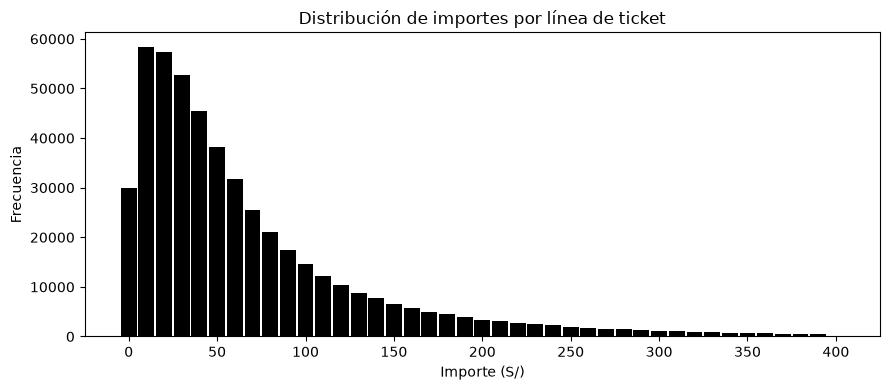

In [29]:
# 10.a  Histograma: la discretización ocurre en el motor
h = con.sql(f"""SELECT floor(importe / 10) * 10 AS bin, count(*) AS n
                FROM '{PQ}' WHERE importe BETWEEN 0 AND 400
                GROUP BY 1 ORDER BY 1""").df()
print(f"filas traídas al cuaderno: {len(h)}   (no 492.830)")
plt.figure(figsize=(9, 4))
plt.bar(h["bin"], h["n"], width=9, color="black")
plt.xlabel("Importe (S/)"); plt.ylabel("Frecuencia")
plt.title("Distribución de importes por línea de ticket")
plt.tight_layout(); plt.show()

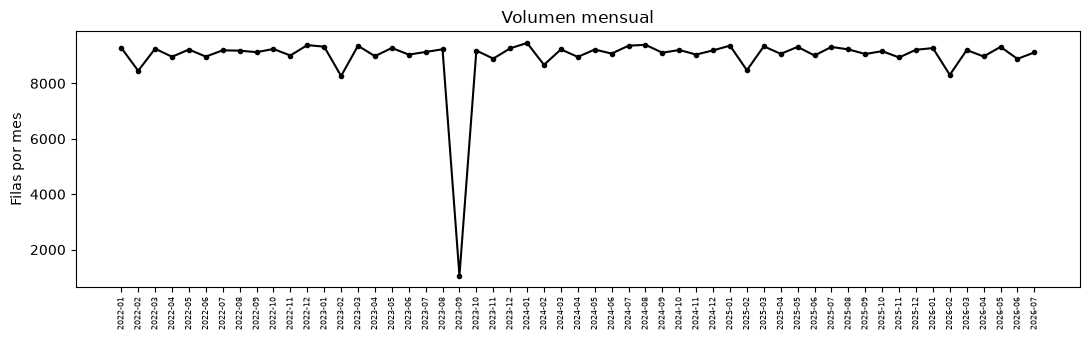

In [30]:
# 10.b  Serie mensual de volumen: el incidente debe verse a simple vista
vol["periodo"] = vol["anio"].astype(str) + "-" + vol["mes"].astype(str).str.zfill(2)
v = vol[vol["anio"] <= 2026].sort_values("periodo")
plt.figure(figsize=(11, 3.5))
plt.plot(v["periodo"], v["n"], color="black", marker="o", markersize=3)
plt.xticks(rotation=90, fontsize=6)
plt.ylabel("Filas por mes"); plt.title("Volumen mensual")
plt.tight_layout(); plt.show()

In [31]:
# P24: porcentaje de filas fuera del rango 0-400 usado en el histograma
total = con.sql(f"SELECT count(*) FROM '{PQ}'").fetchone()[0]
dentro = con.sql(f"SELECT count(*) FROM '{PQ}' WHERE importe BETWEEN 0 AND 400").fetchone()[0]
print(f"total={total:,}  dentro={dentro:,}  fuera={total-dentro:,}  pct_fuera={100*(total-dentro)/total:.2f}%")

total=492,830  dentro=486,796  fuera=6,034  pct_fuera=1.22%


**P24.** El filtro BETWEEN 0 AND 400 deja fuera 6 034 filas de 492 830, es decir, un 1.22% del total. Para el propósito del histograma (ver la forma general de la distribución de importes) me parece aceptable: ese 1.22% corresponde sobre todo a la cola pesada de valores altos (incluyendo los importes contaminados por el precio centinela y las cantidades excesivas), que si se incluyeran aplastarían visualmente el gráfico contra el eje X y no dejarían ver el grueso de la distribución, que es justo lo que sí importa mostrar aquí.

**P25.** Si en vez de agregar en el motor se hubiera hecho `plt.hist()` sobre la columna importe completa traída con to_pandas() (o equivalente), primero se habrían tenido que traer al cuaderno las 492 830 filas completas de esa columna (en vez de las 41 filas que trajo el histograma agregado), lo que consume mucha más memoria y tiempo de transferencia sin necesidad. Y además, como esa columna sin filtrar tiene valores hasta 11 millones de soles (por el precio centinela), matplotlib habría dibujado un histograma con casi todas las barras pegadas al cero y una barra solitaria altísima o invisible en el extremo derecho, dominado por esos pocos outliers, sin mostrar nada útil de la forma real de la distribución.

# Actividad propuesta

El área comercial pide un primer informe de ventas. Antes hay que construir una capa depurada, porque el conjunto crudo tiene duplicados, valores centinela, regiones mal escritas e importes que no cuadran.

## Tarea 1 — Construir la capa depurada

In [32]:
con.sql(f"""
CREATE OR REPLACE VIEW depurado AS
SELECT * REPLACE (
    -- CUZCO es un error de escritura distinto, no se arregla con upper/trim
    CASE
        WHEN regexp_replace(trim(upper(region)), '\\s+', ' ', 'g') = 'CUZCO' THEN 'CUSCO'
        ELSE regexp_replace(trim(upper(region)), '\\s+', ' ', 'g')
    END AS region
)
FROM (SELECT DISTINCT * FROM '{PQ}')
WHERE precio_unitario <> 999999
  AND importe > 0
  AND cantidad <= 500
  AND fecha_hora <= now()
  AND abs(importe - cantidad * precio_unitario) <= 0.05
""")
antes   = con.sql(f"SELECT count(*) FROM '{PQ}'").fetchone()[0]
despues = con.sql("SELECT count(*) FROM depurado").fetchone()[0]
print(f"{antes:,} -> {despues:,}  ({100*(antes-despues)/antes:.2f} % descartado)")
# Comprobación obligatoria: deben quedar exactamente 6 regiones
con.sql("SELECT region, count(*) n FROM depurado GROUP BY 1 ORDER BY 2 DESC").show()

492,830 -> 489,340  (0.71 % descartado)
┌─────────────┬────────┐
│   region    │   n    │
│   varchar   │ int64  │
├─────────────┼────────┤
│ LIMA        │ 254170 │
│ AREQUIPA    │  63733 │
│ LA LIBERTAD │  53961 │
│ PIURA       │  48930 │
│ CUSCO       │  39131 │
│ LAMBAYEQUE  │  29415 │
└─────────────┴────────┘



Quedaron exactamente 6 regiones y se descartó 0.71% de las filas (492 830 → 489 340), tal como se esperaba. La región tuvo que normalizarse en dos pasos: primero trim+upper+colapsar espacios dobles (para las variantes de mayúsculas y de "LA  LIBERTAD" con doble espacio), y aparte un CASE explícito para CUZCO, que es un error de escritura y no se arregla solo mayúsculas y espacios.

## Tarea 2 — Responder las preguntas de negocio

In [33]:
# A: diez productos con mayor importe acumulado en Lima 2026
con.sql("""
SELECT id_producto, round(sum(importe), 2) AS importe_total
FROM depurado
WHERE region = 'LIMA' AND anio = 2026
GROUP BY 1 ORDER BY 2 DESC LIMIT 10
""").show()

┌─────────────┬───────────────┐
│ id_producto │ importe_total │
│   varchar   │    double     │
├─────────────┼───────────────┤
│ P01678      │       2425.82 │
│ P07348      │       2221.76 │
│ P00298      │       2068.62 │
│ P04292      │       2057.87 │
│ P00404      │       1948.13 │
│ P06719      │       1881.63 │
│ P08027      │       1695.65 │
│ P03547      │       1639.23 │
│ P00075      │       1637.49 │
│ P00474      │        1633.1 │
└─────────────┴───────────────┘
  10 rows           2 columns



**A.** El producto con mayor importe acumulado en Lima durante 2026 es P01678 (S/ 2 425.82), seguido de P07348 y P00298. Son montos bastante parejos entre sí (todos entre S/1 600 y S/2 400), no hay un producto que domine muy por encima del resto.

In [34]:
# B: ticket medio por medio de pago, incluyendo los sin informar
con.sql("""
SELECT coalesce(medio_pago, 'SIN_INFORMAR') AS medio_pago,
       count(*) AS n, round(avg(importe), 2) AS ticket_medio
FROM depurado
GROUP BY 1 ORDER BY 3 DESC
""").show()

┌─────────────────┬────────┬──────────────┐
│   medio_pago    │   n    │ ticket_medio │
│     varchar     │ int64  │    double    │
├─────────────────┼────────┼──────────────┤
│ EFECTIVO        │ 164539 │        76.29 │
│ TARJETA_CREDITO │ 101429 │        75.91 │
│ TARJETA_DEBITO  │ 130328 │         75.9 │
│ BILLETERA_MOVIL │  87146 │        75.75 │
│ SIN_INFORMAR    │   5898 │        74.86 │
└─────────────────┴────────┴──────────────┘



**B.** El ticket medio es muy parecido entre todos los medios de pago (entre S/74.86 y S/76.29): EFECTIVO tiene el ticket medio más alto (S/76.29) y los tickets SIN_INFORMAR el más bajo (S/74.86), pero la diferencia es pequeña. No parece que el medio de pago, por sí solo, distinga clientes que gastan mucho más o mucho menos.

In [35]:
# C: categoría con mayor variación % de importe medio entre 2024 y 2026
con.sql("""
WITH c AS (
  SELECT categoria, anio, avg(importe) AS media
  FROM depurado WHERE anio IN (2024, 2026)
  GROUP BY 1, 2
),
resumen AS (
  SELECT categoria,
         max(CASE WHEN anio = 2024 THEN media END) AS media_2024,
         max(CASE WHEN anio = 2026 THEN media END) AS media_2026
  FROM c GROUP BY 1
)
SELECT categoria, round(media_2024, 2) AS media_2024, round(media_2026, 2) AS media_2026,
       round(100.0 * (media_2026 - media_2024) / media_2024, 2) AS variacion_pct
FROM resumen
WHERE media_2024 IS NOT NULL AND media_2026 IS NOT NULL  -- excluye categorías no disponibles en ambos años
ORDER BY variacion_pct DESC
""").show(max_rows=15)

┌───────────────────┬────────────┬────────────┬───────────────┐
│     categoria     │ media_2024 │ media_2026 │ variacion_pct │
│      varchar      │   double   │   double   │    double     │
├───────────────────┼────────────┼────────────┼───────────────┤
│ MASCOTAS          │     228.24 │     286.73 │         25.63 │
│ ABARROTES         │      60.13 │      74.27 │         23.51 │
│ BEBIDAS           │      44.06 │      54.41 │         23.48 │
│ CARNES            │     171.64 │     210.61 │          22.7 │
│ LACTEOS           │      55.32 │      67.85 │         22.65 │
│ CUIDADO PERSONAL  │     134.56 │     164.54 │         22.28 │
│ FRUTAS Y VERDURAS │      38.62 │      47.12 │         21.99 │
│ PANADERIA         │      29.23 │      35.32 │          20.8 │
│ CONGELADOS        │      111.7 │     134.18 │         20.13 │
│ LIMPIEZA          │      87.56 │     105.01 │         19.92 │
└───────────────────┴────────────┴────────────┴───────────────┘
  10 rows                               

**C.** Excluí del ranking cualquier categoría que no tuviera datos en ambos años (con el filtro `media_2024 IS NOT NULL AND media_2026 IS NOT NULL`); en este conjunto todas las 10 categorías presentes en depurado ya tenían datos en 2024 y 2026, así que no se cayó ninguna, pero el filtro es necesario en principio porque no sería justo calcular una "variación porcentual" contra un año en el que la categoría ni siquiera existía (por ejemplo, MASCOTAS no tiene filas antes de 2024, así que su variación solo puede calcularse desde el primer año en que existe, nunca contra 2022 o 2023). La categoría con mayor variación porcentual de importe medio entre 2024 y 2026 fue justamente MASCOTAS, con +25.63% (de S/228.24 a S/286.73), por encima de ABARROTES (+23.51%) y BEBIDAS (+23.48%). Tiene sentido que sea la categoría más nueva la que muestra el mayor crecimiento relativo, reflejando el mismo desplazamiento al alza que ya se había visto con el PSI en el paso 9.

## Tarea 3 — Cuantificar el efecto de la depuración

In [36]:
crudo = con.sql(f"SELECT sum(importe) FROM '{PQ}'").fetchone()[0] / 1e6
dep = con.sql("SELECT sum(importe) FROM depurado").fetchone()[0] / 1e6
print(f"venta total cruda   : {crudo:.3f} millones de soles")
print(f"venta total depurada: {dep:.3f} millones de soles")
print(f"diferencia          : {crudo - dep:.3f} millones de soles")
print(f"filas responsables  : {100*(antes-despues)/antes:.2f} % del total de filas")

venta total cruda   : 1286.853 millones de soles
venta total depurada: 37.187 millones de soles
diferencia          : 1249.665 millones de soles
filas responsables  : 0.71 % del total de filas


La venta total cruda es de 1 286.85 millones de soles, y la venta total sobre la vista depurado es de solo 37.19 millones: la diferencia es de 1 249.67 millones de soles. Esa diferencia se debe fundamentalmente a las 284 filas con precio centinela (999999), que por sí solas inflan la suma en cientos de millones, y en menor medida a las demás filas excluidas (duplicados, cantidades excesivas, importes inconsistentes, fechas futuras). En total, apenas 0.71% de las filas es responsable de casi el 97% de la cifra de venta total cruda.

**Advertencia para el área comercial:** la cifra de venta total calculada directamente sobre los datos crudos del sistema origen (S/ 1 286.85 millones) no es confiable: está inflada en casi 20 veces por un pequeño grupo de registros con precio_unitario = 999999, un valor centinela usado por el sistema origen para "precio no disponible" y no una venta real. Cualquier reporte de ventas debe calcularse sobre la capa depurada (S/ 37.19 millones para el periodo completo), que excluye ese y otros errores de calidad (duplicados, cantidades absurdas, importes que no cuadran con cantidad × precio). Antes de tomar decisiones de negocio sobre esta fuente, se recomienda coordinar con el equipo de sistemas el origen del valor 999999 para corregirlo en el origen y no solo en el análisis.